# Examen Final - Détection de Tweets Suspects avec GiT et DVC

## Partie 1: Exploration et prétraitement des données

### Analyse exploratoire

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

* **Chargeons les donnees avec Pandas**

In [2]:
df = pd.read_csv("../data/raw/tweets_suspect.csv")

df.head()

print(df.shape)
print(df.columns)
print(df.info())

(60000, 2)
Index(['message', 'label'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   message  60000 non-null  str  
 1   label    60000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 937.6 KB
None


* **Vérifions les valeurs manquantes**

0


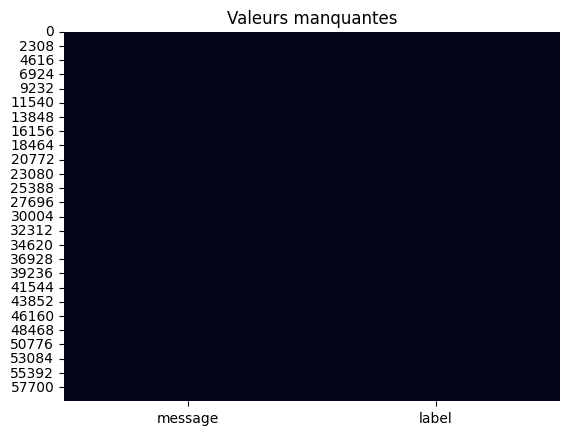

In [3]:
df.isnull().sum()

sns.heatmap(df.isnull(), cbar=False)
plt.title("Valeurs manquantes")
plt.show()

* **Étudier la distribution des classes**

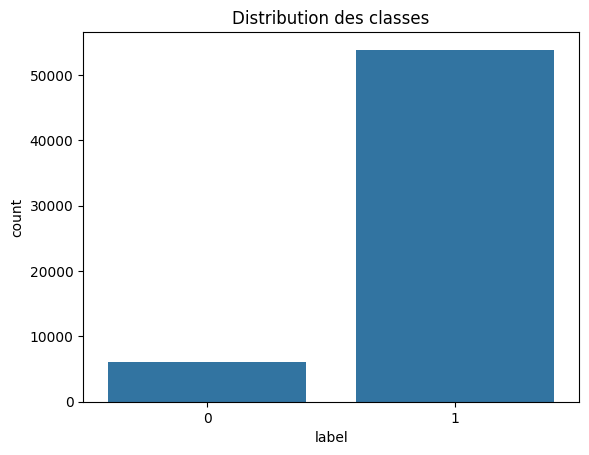

In [4]:
df['label'].value_counts()

sns.countplot(x='label', data=df)
plt.title("Distribution des classes")
plt.show()

### Prétraitement du texte

In [5]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [6]:
def clean_tweet(text):

    # Conversion en minuscules
    text = text.lower()

    # Suppression URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Suppression mentions
    text = re.sub(r'@\w+', '', text)

    # Suppression hashtags
    text = re.sub(r'#', '', text)

    # Suppression ponctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Suppression chiffres
    text = re.sub(r'\d+', '', text)

    words = text.split()

    # Stop words + lemmatisation
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

# Application
df["clean_tweet"] = df["message"].apply(clean_tweet)
df[["message", "clean_tweet"]].head()

# Sauvegarde
# os.makedirs("../data/processed", exist_ok=True)
df.to_csv(
    "../data/processed/clean_tweets.csv",
    index=False
)